<a href="https://colab.research.google.com/github/KaushalKumar-100/Model-Building/blob/main/Model%20Building/Fake_new_predictor/Fake_new_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import kagglehub

In [32]:
from kagglehub import KaggleDatasetAdapter

In [33]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"kaushalkumar1000","key":"981dbd1d44f2038c2c1045fedf7002a0"}'}

In [34]:
!mkdir -p ~/.kaggle

In [35]:
!cp kaggle.json ~/.kaggle/

In [36]:
!chmod 600 ~/.kaggle/kaggle.json


In [37]:
!ls -la ~/.kaggle

total 16
drwxr-xr-x 2 root root 4096 Jun 28 07:14 .
drwx------ 1 root root 4096 Jun 28 07:14 ..
-rw------- 1 root root   72 Jun 28 08:34 kaggle.json


In [38]:
!kaggle datasets download -d saurabhshahane/fake-news-classification

Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
License(s): Attribution 4.0 International (CC BY 4.0)
fake-news-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [39]:
!unzip fake-news-classification.zip

Archive:  fake-news-classification.zip
replace WELFake_Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: WELFake_Dataset.csv     


In [103]:
import re
import pandas as pd
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)



In [41]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x :f"{x:.3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
    'axes.labelsize': 8,
    'axes.labelweight':'bold',
    'xtick.labelsize':8,
    'ytick.labelsize':8
})

RANDOM_STATE=42
CSV_PATH="WELFake_Dataset.csv"
target_col="label"

In [42]:
df=pd.read_csv("WELFake_Dataset.csv")

In [43]:
 df.shape

(72134, 4)

In [48]:
  df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [47]:
df=df.drop(columns=['Unnamed: 0'])

In [50]:
print(df['label'].value_counts(normalize=True))

label
1   0.514
0   0.486
Name: proportion, dtype: float64


In [51]:
df_fake=df[df['label']==0]
df_real=df[df['label']==1]


In [57]:
n_samples=10000
df_fake_sample=df_fake.sample(n_samples,random_state=RANDOM_STATE)
df_real_sample=df_real.sample(n_samples,random_state=RANDOM_STATE)

df=(pd.concat([df_fake_sample,df_real_sample])
              .sample(frac=1,random_state=RANDOM_STATE)
              .reset_index(drop=True)

)

In [58]:
df.shape

(20000, 3)

In [59]:
df.head()

,title,text,label
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1


In [60]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   19867 non-null  object
 1   text    19989 non-null  object
 2   label   20000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 468.9+ KB


In [61]:
df.isnull().sum()

,0
title,133
text,11
label,0


In [62]:
df=df.dropna()

In [63]:
df['label'].value_counts()

,count
label,
0,10000
1,9856


In [64]:
df['text'].head(2)

,text
0,"Did America really expect this racist, Communi..."
1,(Reuters) - Pennsylvania Governor Tom Wolf sig...


Cleaning the Text

In [65]:
def clean_text(s:str)->str:
  "Simple text cleannin"
  "Lowercasting"
  "Remove urls"
  "remove Htmls"
  "normalize space"
  "keep letters/numbers and basic pantuation"
  if pd.isna(s):
    return ""

  s=str(s).lower()
  s=re.sub(r"http\S+|www\.\S+"," ",s)
  s=re.sub(r"<.*?>"," ",s)
  s=re.sub(r"[^a-z0-9\s\.\,\?\-\']"," ",s)
  s=re.sub(r"\s+"," ",s).strip()
  return s



In [67]:
df.head(1)

,title,text,label
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1


In [68]:
df['content']=(df['title']+" "+df['text']).apply(clean_text)

In [69]:
df.head(2)

,title,text,label,content
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1,breaking obama s war on cops another cop ambus...
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0,pennsylvania bans bias against transgender peo...


adding additional columns for analysis

In [71]:
df['title_len_chars']=df['title'].str.len()
df['text_len_chars']=df['text'].str.len()
df['content_len_chars']=df['content'].str.split().apply(len)

df.head()



,title,text,label,content,title_len_chars,text_len_chars,content_len_chars
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1,breaking obama s war on cops another cop ambus...,134,5854,1031
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0,pennsylvania bans bias against transgender peo...,49,751,115
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0,u.s. lawmakers aim to comply with iran nuclear...,55,2736,468
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0,more than 60 killed in air strike on syrian ma...,55,1775,300
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1,virginia republican says conservatives own chr...,100,3451,593


In [72]:
nums_cols=["title_len_chars",'text_len_chars','content_len_chars']

In [73]:
df[nums_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
title_len_chars,19856.000,76.993,25.072,4.000,62.000,73.000,89.000,286.000
text_len_chars,19856.000,3283.625,3658.956,1.000,1414.750,2435.000,4081.500,115372.000
content_len_chars,19856.000,558.641,621.057,0.000,244.000,414.000,687.000,21284.000


In [83]:
counts=df['label'].value_counts().sort_index()

In [87]:
counts.values

array([10000,  9856])

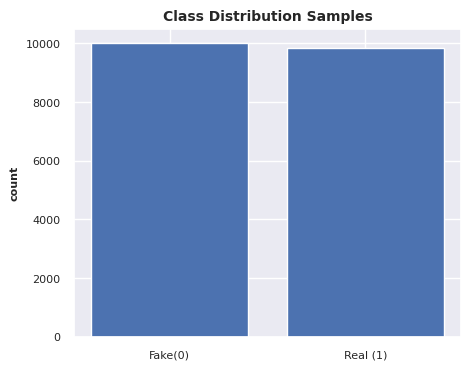

In [88]:
plt.figure(figsize=(5,4))
plt.bar(['Fake(0)',"Real (1)"],counts.values)
plt.title("Class Distribution Samples")
plt.ylabel("count")
plt.show()

In [93]:
fake_lens=df[df['label']==0]['content_len_chars'].values
real_lens=df[df['label']==1]['content_len_chars'].values


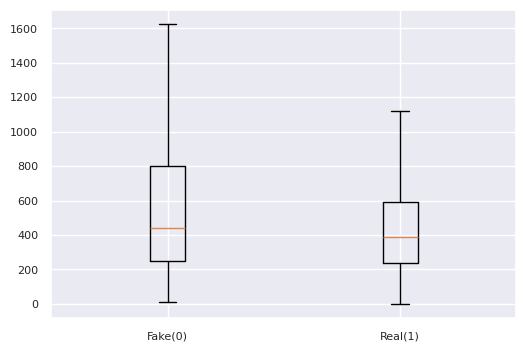

In [98]:
plt.figure(figsize=(6,4))
plt.boxplot([fake_lens,real_lens],
            tick_labels=["Fake(0)","Real(1)"],
            showfliers=False)


plt.show()

Separate features and target

In [99]:
X=df['content']
y=df['label']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=RANDOM_STATE
)


In [100]:
X_train.shape

(15884,)

Vectorization and model Training

In [108]:
model_pipeline=Pipeline(
    steps=[
        ("tfidf",TfidfVectorizer(
            max_features=10000,
            ngram_range=(1,2),
            stop_words="english",
            min_df=2
        )),
        ("model",LogisticRegression())
    ]
)

In [109]:
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english')),
                ('model', LogisticRegression())])

Model Evaluation

In [111]:
y_train_pred=model_pipeline.predict(X_train)
y_train_pred_prob=model_pipeline.predict_proba(X_train)[:,1]
y_test_pred=model_pipeline.predict(X_test)

acc_train=accuracy_score(y_train,y_train_pred)
acc_test=accuracy_score(y_test,y_test_pred)


confusion_matrix_train=confusion_matrix(y_train,y_train_pred)
confusion_matrix_test=confusion_matrix(y_test,y_test_pred)


print("\n ----train metrics----------")
print(f"accuracy score: {acc_train}")
print(f"confusion matrix:\n{confusion_matrix_train}")

print("classification report\n",classification_report(y_train,y_train_pred))


 ----train metrics----------
accuracy score: 0.9524049357844372
confusion matrix:
[[7582  418]
 [ 338 7546]]
classification report
               precision    recall  f1-score   support

           0       0.96      0.95      0.95      8000
           1       0.95      0.96      0.95      7884

    accuracy                           0.95     15884
   macro avg       0.95      0.95      0.95     15884
weighted avg       0.95      0.95      0.95     15884



In [112]:
print("\n ----test metrics----------")
print(f"accuracy score: {acc_test}")
print(f"confusion matrix:\n{confusion_matrix_test}")
print("classification report",classification_report(y_test,y_test_pred))



 ----test metrics----------
accuracy score: 0.9350453172205438
confusion matrix:
[[1864  136]
 [ 122 1850]]
classification report               precision    recall  f1-score   support

           0       0.94      0.93      0.94      2000
           1       0.93      0.94      0.93      1972

    accuracy                           0.94      3972
   macro avg       0.94      0.94      0.94      3972
weighted avg       0.94      0.94      0.94      3972



Predictive system

In [117]:
def predictive_news(title,text):
  combined=clean_text(f"{title} {text}")
  prediction=model_pipeline.predict([combined])
  print(prediction)
  if prediction[0]==1:
    print("This is a Real News 🟢")
  else:
    print("This is a Fake news :🔴")


In [ ]:
example_title=""
example_text=""
predictive_news(example_title,example_text)

In [118]:
!git clone https://github.com/KaushalKumar-100/Model-Building/tree/main/Model%20Building

Cloning into 'Model%20Building'...
fatal: repository 'https://github.com/KaushalKumar-100/Model-Building/tree/main/Model%20Building/' not found


In [125]:
!git clone https://github.com/KaushalKumar-100/Model-Building

fatal: destination path 'Model-Building' already exists and is not an empty directory.
